# Imports

In [131]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
    
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import random
from math import sqrt
from sklearn.metrics import mean_squared_error

from waterquality.DataHandler import DataLoader, DataPreparation, Reader
from waterquality.Model import Model
from waterquality.Utils import boxplot, plot_predictions, plot_prediction_sequence, plot_single_prediction
from waterquality.Pipeline import Pipeline

%load_ext autoreload
%autoreload 2

np.set_printoptions(suppress=True)
# np.set_printoptions(threshold=sys.maxsize)
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data

In [132]:
loader = DataLoader("../data/amerigo.xlsx")
loader.slice_data("Data", 44212, 44527)
loader.handle_na()

In [133]:
data = loader.data.copy()
data.drop(['Data', 'Ora Solare', 'Turbidity [FNU]', 'Pioggia Fit [mm]'], axis=1, inplace=True)
data.set_index("Data + Ora Solare", inplace = True)

In [ ]:
# data.describe().transpose()

# Data Preparation

In [134]:
timesteps_in = 120
timesteps_out = 24
train_X, train_y, test_X, test_y = DataPreparation.create_dataset(
    data, 
    "DOC formula", 
    5000, 
    timesteps_in=timesteps_in, 
    timesteps_out=timesteps_out
)
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

(5000, 120, 10) (5000, 24) (1947, 120, 10) (1947, 24)


# Model

In [136]:
input_shape = (train_X.shape[1], train_X.shape[2])
model = Model(input_shape, output=timesteps_out)

In [137]:
history = model.fit(train_X, train_y, validation_data=(test_X, test_y))

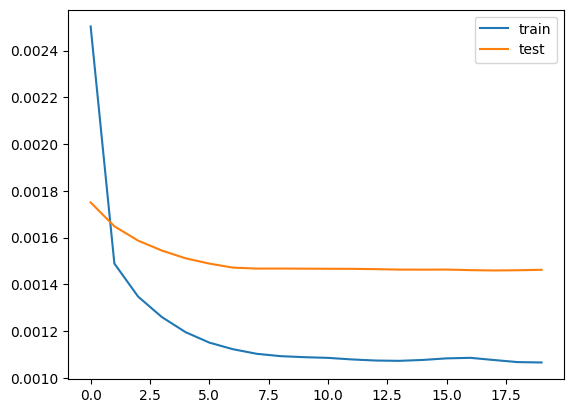

In [138]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.savefig("testimage.png", bbox_inches='tight')
plt.show()

# Predictions

In [139]:
yhat = model.predict(test_X)
yhat = DataPreparation.inverse_transform_y(yhat, test_X.shape[2])

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [140]:
real_y = DataPreparation.inverse_transform_y(test_y, test_X.shape[2])

In [141]:
rmse = sqrt(mean_squared_error(real_y, yhat))
print('Test RMSE: %.3f' % rmse)

Test RMSE: 1.140


In [142]:
plot_predictions(real_y, yhat)

Plotting sequence prediction for the whole dataset is not available


# Outliers

In [ ]:
loader.data.describe()

check outliers and try to predict DOC without outliers

In [ ]:
boxplot(loader.data, loader.data.columns[3:])

In [ ]:
loader.data.columns

In [ ]:
def find_outliers_IQR(df):
   q1=df.quantile(0.25)
   q3=df.quantile(0.75)
   IQR=q3-q1
   outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]
   return outliers

In [ ]:
outliers = find_outliers_IQR(loader.data['Pioggia Fit [mm]'])

In [ ]:
outliers.describe()

In [ ]:
len(outliers)

In [ ]:
len(loader.data)

In [ ]:
outliers.isna().sum()

# Pipeline 

In [2]:
pipeline = Pipeline('../data/Fitterizzi_output.csv', "../data/Meteo Agosto 22 - Luglio 23.xlsx")

In [3]:
pipeline.load_files()

In [4]:
pipeline.slice_data()

In [5]:
pipeline.add_doc_formula_values()

In [6]:
pipeline.handle_missing_values()

In [7]:
pipeline.drop_columns()

In [8]:
pipeline.merge_data_sources()

In [9]:
pipeline.align_start_date()

In [318]:
pipeline.create_dataset(timesteps_in=120, timesteps_out=1)

In [325]:
pipeline.create_model(output=1)

In [326]:
pipeline.train_model(30, plot=False)

Epoch 1/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0016 - val_loss: 4.1292e-04
Epoch 2/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0012 - val_loss: 3.7161e-04
Epoch 3/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0013 - val_loss: 4.0622e-04
Epoch 4/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0012 - val_loss: 4.4758e-04
Epoch 5/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 9.8036e-04 - val_loss: 2.8915e-04
Epoch 6/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 8.7391e-04 - val_loss: 2.9443e-04
Epoch 7/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 7.0504e-04 - val_loss: 3.0071e-04
Epoch 8/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 5.6305e-04 - val_loss: 2.1538e-04
Epoch 9/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 4.2537e-04 - val_loss: 1.3949e-04
Epoch 10/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 3.2095e-04 - val_loss: 1.4082e-04
Epoch 11/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 3.2

207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Test RMSE: 0.429


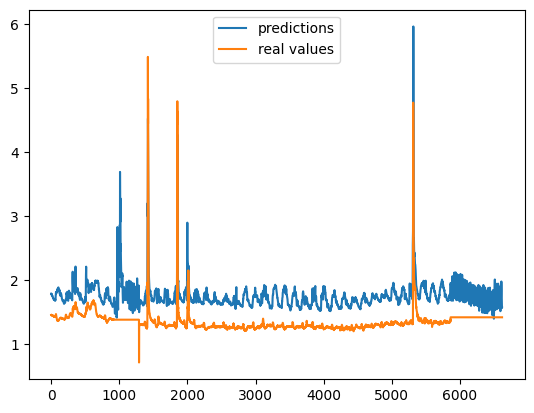

In [327]:
pipeline.evaluate_model(plot=True)

In [ ]:
pipeline.model.model.input_shape

In [ ]:
pipeline.model.model.output_shape

# Trash

In [ ]:
input_shape = (train_X.shape[1], train_X.shape[2])
model_test = Model(input_shape, output=timesteps_out)
history_test = model_test.fit(train_X, train_y, validation_data=(test_X, test_y), epochs=10)
plt.plot(history_test.history['loss'], label='train')
plt.plot(history_test.history['val_loss'], label='test')
plt.legend()
plt.show()

In [ ]:
X_values = test_X[0, :]
Y_values = test_y[0]

In [ ]:
n_columns = X_values.shape[1]
p = model_test.predict(X_values, DataPreparation.scaler)
real = DataPreparation.inverse_transform_y(p, n_columns)
predictions = real.reshape(real.shape[1])
rescaled_past_values = DataPreparation.inverse_transform_y(X_values[:,0].reshape(1, X_values.shape[0]), n_columns)
rescaled_past_values = rescaled_past_values[0,:]
rescaled_future_values = DataPreparation.inverse_transform_y(Y_values.reshape(1, Y_values.shape[0]), n_columns)
rescaled_future_values = rescaled_future_values[0,:]

In [ ]:
plot_prediction_sequence(predictions, rescaled_past_values, rescaled_future_values)

In [ ]:
rmse = sqrt(mean_squared_error(real_future, pred))
print('Test RMSE: %.3f' % rmse)

In [ ]:
# np.concatenate((train_X[:2], train_X[2:4]), axis=0) == train_X[:4]

In [ ]:
all_data_X = np.concatenate((pipeline.train_X, pipeline.validation_X, pipeline.test_X), axis=0)
all_data_y = np.concatenate((pipeline.train_y, pipeline.validation_y, pipeline.test_y), axis=0)


yhat = pipeline.model.predict(pipeline.validation_X)
yhat = DataPreparation.inverse_transform_y(yhat, pipeline.validation_X.shape[2])
real_y = DataPreparation.inverse_transform_y(pipeline.validation_y, pipeline.validation_X.shape[2])

rmse = sqrt(mean_squared_error(real_y, yhat))
print('Test RMSE: %.3f' % rmse)
# plt.plot(real_y, label='real values')
# plt.plot(yhat, label='predictions')
# plt.legend()
# plt.show()  

In [331]:
pipeline.model.model = pipeline.best_model

In [217]:
# pipeline.model.model.summary()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
RMSE: 0.079


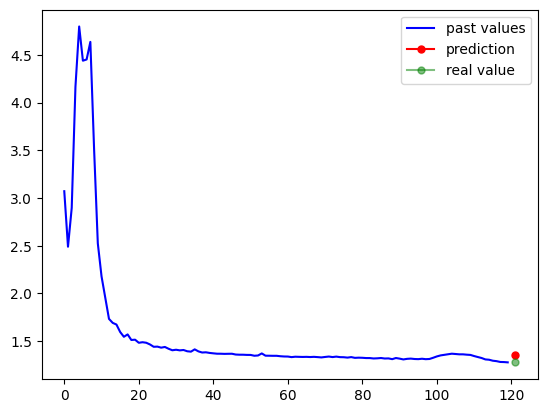

[1.35577922]
[1.276378]
rmse:  0.07940122199530841


In [364]:
# random_sample = pipeline.merged_data.iloc[120:240].values
# random_sample_real_output = pipeline.merged_data.iloc[240:264].values
# random_sample, random_sample_real_output = pipeline.pick_random_sample()
# print(pipeline.train_X.shape, random_sample_real_output.shape)
p = pipeline.predict_single_value(random_sample, y=random_sample_real_output, plot=True)
print(p)
print(random_sample_real_output[:,0])
mse = ((p - random_sample_real_output[:,0])**2).mean()
rmse = np.sqrt(mse)
print("rmse: ", rmse)

# Hyperparameter Tuning

In [329]:
pipeline.hyperparameter_tuning(epochs=20, max_trials=50, executions_per_trial=1)

Trial 50 Complete [00h 01m 56s]
val_mse: 4.0250655729323626e-05

Best val_mse So Far: 1.9543178495950997e-05
Total elapsed time: 02h 27m 18s


/home/luis/.local/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 36 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [330]:
pipeline.best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 120, 96)        │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 120, 64)        │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 120, 96)        │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120, 96)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120, 128)       │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 309,185 (1.18 MB)

 Trainable params: 309,185 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

In [245]:
yhat = pipeline.best_model.predict(pipeline.test_X)
yhat = DataPreparation.inverse_transform_y(yhat, pipeline.test_X.shape[2])
real_y = DataPreparation.inverse_transform_y(pipeline.test_y, pipeline.test_X.shape[2])

rmse = sqrt(mean_squared_error(real_y, yhat))
print('Test RMSE: %.3f' % rmse)
plot_predictions(real_y, yhat)

207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Test RMSE: 0.910
Plotting sequence prediction for the whole dataset is not available
